Paquetes necesarios

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

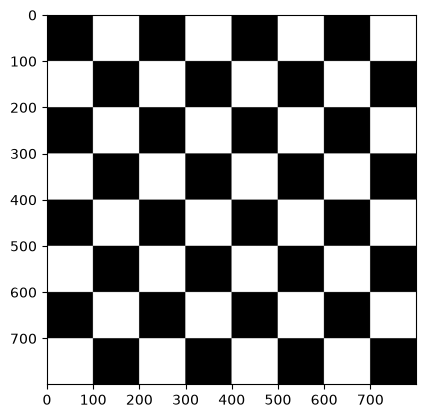

In [2]:
# Hecho manualmente

squares = 8
size = 100
tablero_img = np.zeros((squares*size,squares*size,1))
for row in range(0, squares):
    for col in range(0, squares):
        if (row+col)%2 == 1:
            tablero_img[row*size:(row+1)*size, col*size:(col+1)*size,0] = 255

plt.imshow(tablero_img, cmap='gray')
plt.show()

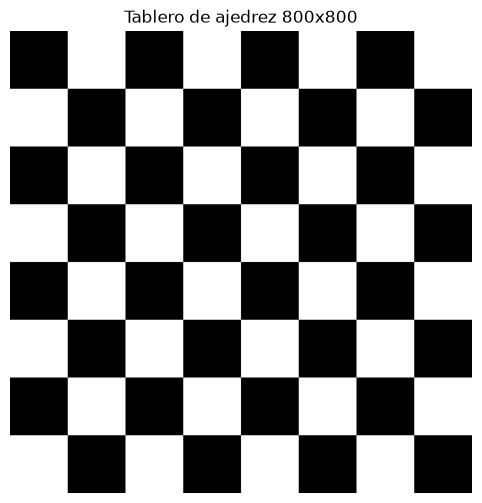

In [3]:
# Hecho por Claude Opus 4.8

tam_recuadro, n = 100, 8
# Patrón 8x8 de 0 y 1
patron = np.indices((n, n)).sum(axis=0) % 2
# Escalar a 800x800 y pasar a 0/255
tablero = np.kron(patron, np.ones((tam_recuadro, tam_recuadro))) * 255
# Forzar uint8 (esta es la línea clave)
tablero = tablero.astype(np.uint8)
# Convertir a 3 canales
tablero = cv2.cvtColor(tablero, cv2.COLOR_GRAY2BGR)

plt.figure(figsize=(6, 6))
plt.imshow(tablero)
plt.axis("off")
plt.title("Tablero de ajedrez 800x800")
plt.show()

# Comparativa
Mientras que nosotros creamos la imagen desde cero e iteramos para pintar el patrón directamente en la imagen, la IA crea primero el patrón y luego lo escala a las dimensiones de la imagen. <br>
Cabe destacar que la IA decidió por algún motivo, cambiar los canales de escala de gris a BGR.

**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

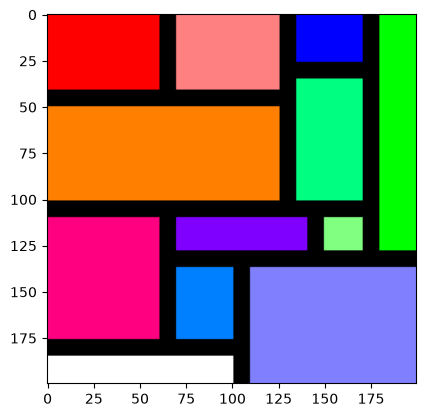

In [4]:
# Imagen de Sergio

#Crea una imagen con tres planos
color_img = np.zeros((200,200,3), dtype = np.uint8)

#Rectángulo relleno
cv2.rectangle(color_img,(0,0),(60,40),(255,0,0),-1)
cv2.rectangle(color_img,(0,50),(125,100),(255,128,0),-1)
cv2.rectangle(color_img,(0,110),(60,175),(255,0,128),-1)
cv2.rectangle(color_img,(0,185),(100,200),(255,255,255),-1)
cv2.rectangle(color_img,(70,0),(125,40),(255,128,128),-1)
cv2.rectangle(color_img,(70,110),(140,127),(128,0,255),-1)
cv2.rectangle(color_img,(70,137),(100,175),(0,128,255),-1)
cv2.rectangle(color_img,(110,137),(200,200),(128,128,255),-1)
cv2.rectangle(color_img,(135,0),(170,25),(0,0,255),-1)
cv2.rectangle(color_img,(180,0),(2000,127),(0,255,0),-1)
cv2.rectangle(color_img,(135,35),(170,100),(0,255,128),-1)
cv2.rectangle(color_img,(150,110),(170,127),(128,255,128),-1)
#Visualiza sin especificar el mapa de color gris
plt.imshow(color_img) 
plt.show()

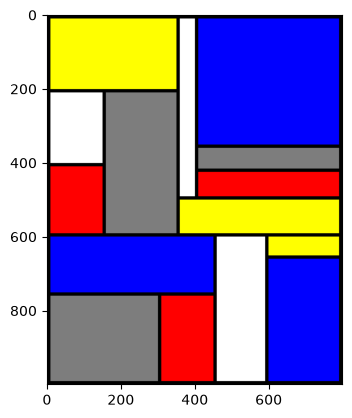

In [5]:
# Imagen de Arael

modrian_img = np.zeros((1000,800,3),dtype=np.uint8)
cv2.rectangle(modrian_img,(10,10),(350,200),(255,255,0),-1)
cv2.rectangle(modrian_img,(360,10),(400,490),(255,255,255),-1)
cv2.rectangle(modrian_img,(10,210),(150,400),(255,255,255),-1)
cv2.rectangle(modrian_img,(410,10),(790,350),(0,0,255),-1)
cv2.rectangle(modrian_img, (160, 210), (350, 590), (125,125,125), -1)
cv2.rectangle(modrian_img, (10, 410), (150, 590), (255, 0, 0), -1)
cv2.rectangle(modrian_img, (360,500),(790,590),(255,255,0),-1)
cv2.rectangle(modrian_img, (410,360),(790,415),(125,125,125),-1)
cv2.rectangle(modrian_img, (410, 425), (790,490),(255,0,0),-1)
cv2.rectangle(modrian_img, (10, 600), (450,750),(0,0,255),-1)
cv2.rectangle(modrian_img, (460, 600), (590,990),(255,255,255),-1)
cv2.rectangle(modrian_img,(600,600),(790,650),(255,255,0),-1)
cv2.rectangle(modrian_img,(600,660),(790,990),(0,0,255),-1)
cv2.rectangle(modrian_img,(10,760),(300,990),(125,125,125),-1)
cv2.rectangle(modrian_img,(310,760),(450,990),(255,0,0),-1)
plt.imshow(modrian_img)
plt.show()


**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


In [6]:
vid = cv2.VideoCapture(0)
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()
    if ret: 
        newFrame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        for y,x in np.argwhere(newFrame == newFrame.max()):
            cv2.circle(frame,(x,y), 5, (0,0,0), -1)
        for y,x in np.argwhere(newFrame == newFrame.min()):
            cv2.circle(frame,(x,y), 5, (255,255,255), -1)
        cv2.imshow('Cam', frame)   
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

El código va fluido, aunque debido a la diferencia entre fotogramas los puntos pueden variar de manera errática, dando lugar a una sensación de saltos.

TAREA: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

In [7]:
vid = cv2.VideoCapture(0)

#Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

#Fuerzo a mitad de resolución para ocupar menos pantalla
w=int(w/2)
h=int(h/2)
vid.set(cv2.CAP_PROP_FRAME_WIDTH, w) #En Mac no reacciona a estos comandos
vid.set(cv2.CAP_PROP_FRAME_HEIGHT, h)

#Imagen conjunta 2x original
collage = np.zeros((h*2,w*2,3), dtype = np.uint8)
tl = collage[0:h,0:w]
tr = collage[0:h,w:w+w]
bl = collage[h:h+h,0:w]
br = collage[h:h+h,w:w+w]

numLineas = 10
alto = h//(numLineas*2)
ancho = w//(numLineas*2)
collageMask = np.ones((h*2,w*2,3), dtype = np.float32)
tlMask = collageMask[0:h,0:w]
trMask = collageMask[0:h,w:w+w]
blMask = collageMask[h:h+h,0:w]
brMask = collageMask[h:h+h,w:w+w]

for i in range(numLineas*2):
    if i%2 ==0:
        trMask[:,i*ancho:(i+1)*ancho] = np.array([175,75,235], dtype=np.float32)/255
        blMask[i*alto: (i+1)*alto,:] = np.array([75,235,175], dtype=np.float32)/255
    else:
        trMask[:,i*ancho:(i+1)*ancho] = np.array([80,180,20], dtype=np.float32)/255
        blMask[i*alto: (i+1)*alto,:] = np.array([180,20,80], dtype=np.float32)/255
brMask[:,:,:] = (trMask[:,:,:] + blMask[:,:,:])/2

while True:      
    # fotograma a fotograma
    ret, frameIN = vid.read()

    #Menor tamaño
    frame = cv2.resize(frameIN, (int(w),int(h)),cv2.INTER_NEAREST)

    if ret:
        tr[:,:,:] = frame[:,:,:]
        tl[:,:,:] = frame[:,:,:]
        bl[:,:,:] = frame[:,:,:]
        br[:,:,:] = frame[:,:,:]

        collage[:,:,:] = (collage[:,:,:] * collageMask[:,:,:])//1
    
        # Muestra composición
        cv2.imshow('Cam', collage)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()